# Lab 04 - Câu 3: A2C from Scratch (CartPole-v1)

Notebook này dành riêng cho câu 3: đọc ý tưởng từ Stable-Baselines3 và tự hiện thực A2C.

## Mục tiêu bắt buộc
1. Cài đặt Advantage
2. Cơ chế update theo batch rollout
3. Entropy bonus (nếu có)
4. Đánh giá trên CartPole-v1

In [183]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## A2C Network (Actor-Critic chung backbone)

In [184]:
class A2CNet(nn.Module):
    def __init__(self, state_dim=4, hidden_dim=128, action_dim=2):
        super().__init__()
        
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
        )
        
        self.actor_head = nn.Linear(hidden_dim, action_dim)
        self.critic_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = self.backbone(x)
        
        logits = self.actor_head(h)
        value = self.critic_head(h).squeeze(-1)
        return logits, value

## TODO: Hoàn thiện các hàm A2C
- `collect_rollout(...)`
- `compute_advantages(...)`
- `a2c_update(...)`
- `train_a2c_cartpole(...)`

In [185]:
def collect_rollout(env, model, rollout_steps=32, gamma=0.99):
    states = []
    actions = []
    rewards = []
    dones = []
    log_probs = []
    values = []

    state, _ = env.reset()

    for _ in range(rollout_steps):
        state_tensor = torch.FloatTensor(state).to(device)

        logits, value = model(state_tensor)

        dist = Categorical(logits=logits)
        action = dist.sample()

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        states.append(state)
        actions.append(action)
        rewards.append(reward)
        dones.append(done)
        log_probs.append(dist.log_prob(action))
        values.append(value)

        state = next_state

        if done:
            state, _ = env.reset()

    next_state_tensor = torch.FloatTensor(state).to(device)

    with torch.no_grad():
        _, next_value = model(next_state_tensor)

    return {
        "states": torch.FloatTensor(np.array(states)).to(device),
        "actions": torch.stack(actions),
        "rewards": torch.FloatTensor(rewards).to(device),
        "dones": torch.FloatTensor(dones).to(device),
        "log_probs": torch.stack(log_probs),
        "values": torch.stack(values),
        "next_value": next_value.detach()
    }

In [186]:
def compute_advantages(rewards, values, dones, next_value, gamma=0.99):
    returns = []
    R = next_value

    for step in reversed(range(len(rewards))):
        R = rewards[step] + gamma * R * (1.0 - dones[step])
        returns.insert(0, R)

    returns = torch.stack(returns)
    
    advantages = returns - values  
    advantages = advantages / (advantages.std() + 1e-8)

    return returns.detach(), advantages.detach()

In [187]:
def a2c_update(model,
               optimizer,
               rollout_data,
               gamma=0.99,
               value_coef=0.5,
               entropy_coef=0.01):

    rewards = rollout_data["rewards"]
    values = rollout_data["values"]
    dones = rollout_data["dones"]
    log_probs = rollout_data["log_probs"]
    states = rollout_data["states"]
    actions = rollout_data["actions"]
    next_value = rollout_data["next_value"]

    returns, advantages = compute_advantages(
        rewards,
        values,
        dones,
        next_value,
        gamma
    )

    logits, new_values = model(states)

    dist = Categorical(logits=logits)

    new_log_probs = dist.log_prob(actions)

    entropy = dist.entropy().mean()

    actor_loss = -(new_log_probs * advantages).mean()

    critic_loss = (returns - new_values).pow(2).mean()

    loss = actor_loss + value_coef * critic_loss - entropy_coef * entropy

    optimizer.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

    optimizer.step()

    return (
        loss.item(),
        actor_loss.item(),
        critic_loss.item(),
        entropy.item()
    )

In [ ]:
def train_a2c_cartpole(
    total_updates=500,
    rollout_steps=256,
    gamma=0.99,
    lr=8e-4,
):

    env = gym.make("CartPole-v1")

    model = A2CNet().to(device)

    optimizer = optim.Adam([
        {"params": model.shared.parameters(), "lr": 8e-4},
        {"params": model.actor.parameters(),  "lr": 8e-4},
        {"params": model.critic.parameters(), "lr": 3e-4},
    ])

    reward_history = []

    state, _ = env.reset()

    episode_reward = 0

    for update in range(total_updates):

        states = []
        actions = []
        rewards = []
        dones = []
        log_probs = []
        values = []

        for _ in range(rollout_steps):

            state_tensor = torch.FloatTensor(state).to(device)

            logits, value = model(state_tensor)

            dist = Categorical(logits=logits)

            action = dist.sample()

            next_state, reward, terminated, truncated, _ = env.step(action.item())

            done = terminated or truncated

            states.append(state)
            actions.append(action)
            rewards.append(reward)
            dones.append(done)
            log_probs.append(dist.log_prob(action))
            values.append(value)

            episode_reward += reward

            state = next_state

            if done:
                reward_history.append(episode_reward)

                state, _ = env.reset()

                episode_reward = 0

        next_state_tensor = torch.FloatTensor(state).to(device)

        with torch.no_grad():
            _, next_value = model(next_state_tensor)

        rollout_data = {
            "states": torch.FloatTensor(np.array(states)).to(device),
            "actions": torch.stack(actions),
            "rewards": torch.FloatTensor(rewards).to(device),
            "dones": torch.FloatTensor(dones).to(device),
            "log_probs": torch.stack(log_probs),
            "values": torch.stack(values),
            "next_value": next_value.detach()
        }

        loss, actor_loss, critic_loss, entropy = a2c_update(
            model,
            optimizer,
            rollout_data,
            gamma=gamma
        )

        if (update + 1) % 20 == 0 and len(reward_history) > 0:

            avg_reward = np.mean(reward_history[-20:])

            print(
                f"Update {update+1:3d} | "
                f"Avg Reward: {avg_reward:.2f} | "
                f"Loss: {loss:.4f} | "
                f"Actor: {actor_loss:.4f} | "
                f"Critic: {critic_loss:.4f} | "
                f"Entropy: {entropy:.4f}"
            )

    env.close()

    return model, reward_history

Update  20 | Avg Reward: 16.90 | Loss: 66.2748 | Actor: 1.0311 | Critic: 130.5013 | Entropy: 0.6913
Update  40 | Avg Reward: 28.20 | Loss: 279.8247 | Actor: 0.7814 | Critic: 558.1005 | Entropy: 0.6877
Update  60 | Avg Reward: 37.35 | Loss: 884.2001 | Actor: 1.0405 | Critic: 1766.3330 | Entropy: 0.6832
Update  80 | Avg Reward: 44.80 | Loss: 281.5212 | Actor: 0.9757 | Critic: 561.1044 | Entropy: 0.6680
Update 100 | Avg Reward: 49.20 | Loss: 276.0091 | Actor: 0.9758 | Critic: 550.0797 | Entropy: 0.6548
Update 120 | Avg Reward: 43.55 | Loss: 281.3541 | Actor: 0.9758 | Critic: 560.7696 | Entropy: 0.6474
Update 140 | Avg Reward: 65.45 | Loss: 508.9949 | Actor: 0.8514 | Critic: 1016.3000 | Entropy: 0.6507
Update 160 | Avg Reward: 64.55 | Loss: 359.4776 | Actor: 0.8262 | Critic: 717.3154 | Entropy: 0.6261
Update 180 | Avg Reward: 79.35 | Loss: 1412.9707 | Actor: 1.0572 | Critic: 2823.8394 | Entropy: 0.6173
Update 200 | Avg Reward: 92.10 | Loss: 514.9479 | Actor: 0.9485 | Critic: 1028.0112 | En

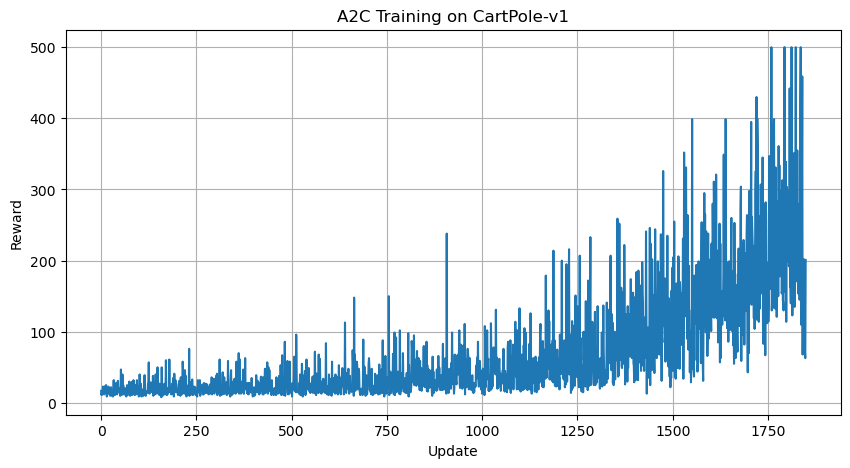

In [189]:
model, rewards = train_a2c_cartpole()

plt.figure(figsize=(10, 5))
plt.plot(rewards)
plt.xlabel("Update")
plt.ylabel("Reward")
plt.title("A2C Training on CartPole-v1")
plt.grid(True)
plt.show()

## TODO: Đánh giá và báo cáo
- So sánh với A2C từ Stable-Baselines3
- Nêu rõ Advantage, batch update, entropy bonus đã dùng